# Capstone Project: Day 4 - Fund Performance Analytics

**Objective:** Compute mathematical risk and performance metrics to evaluate mutual funds compared to the market.

- **CAGR (1yr, 3yr, 5yr):** Actual annualized percentage growth.
- **Sharpe Ratio:** Risk-adjusted return.
- **Sortino Ratio:** Downside risk-adjusted return.
- **Alpha:** Excess return over the benchmark.
- **Beta:** Volatility relative to the market.
- **Maximum Drawdown:** Worst peak-to-trough decline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# Ensure processed folder exists
os.makedirs('../data/processed', exist_ok=True)

### 1. Daily Returns & CAGR (1yr, 3yr, 5yr)

In [2]:
nav_path = '../data/raw/02_nav_history.csv'
if os.path.exists(nav_path):
    df_nav = pd.read_csv(nav_path)
    df_nav['date'] = pd.to_datetime(df_nav['date'])
    df_nav = df_nav.sort_values(['amfi_code', 'date'])
    
    # Compute Daily Return
    df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()
    
    # Compute CAGR for 1, 3, 5 years
    def compute_cagrs(group):
        group = group.dropna(subset=['nav'])
        if len(group) < 252:
            return pd.Series({'1yr_cagr': np.nan, '3yr_cagr': np.nan, '5yr_cagr': np.nan})
            
        latest_nav = group['nav'].iloc[-1]
        
        # Approximate trading days: 1yr=252, 3yr=756, 5yr=1260
        res = {}
        for yrs, days in zip([1, 3, 5], [252, 756, 1260]):
            if len(group) > days:
                start_nav = group['nav'].iloc[-days]
                cagr = ((latest_nav / start_nav) ** (1/yrs)) - 1
                res[f'{yrs}yr_cagr'] = cagr
            else:
                # Use total available days if less than required (for 5yr if dataset is 4.5yr)
                total_years = len(group) / 252
                start_nav = group['nav'].iloc[0]
                cagr = ((latest_nav / start_nav) ** (1/total_years)) - 1
                res[f'{yrs}yr_cagr'] = cagr if yrs == 5 else np.nan # only fallback for 5yr
        return pd.Series(res)
        
    cagr_report = df_nav.groupby('amfi_code').apply(compute_cagrs).reset_index()
    cagr_report.to_csv('../data/processed/cagr_report.csv', index=False)
    print("CAGR report generated and saved.")
    display(cagr_report.head())

CAGR report generated and saved.


,amfi_code,1yr_cagr,3yr_cagr,5yr_cagr
0,100016,-0.033055,-0.000316,0.025412
1,100025,0.025018,0.046143,0.042948
2,100033,0.477346,0.336292,0.288994
3,101206,0.450939,0.325286,0.226048
4,101207,-0.242421,-0.026965,0.076433


### 2. Sharpe Ratio & Sortino Ratio

In [3]:
if os.path.exists(nav_path):
    risk_free_rate = 0.065 # 6.5%
    
    # Sharpe Ratio
    volatility = df_nav.groupby('amfi_code')['daily_return'].std() * np.sqrt(252)
    annual_return = df_nav.groupby('amfi_code')['daily_return'].mean() * 252
    sharpe_ratios = (annual_return - risk_free_rate) / volatility
    
    df_sharpe = sharpe_ratios.reset_index(name='sharpe_ratio')
    df_sharpe.to_csv('../data/processed/sharpe_values.csv', index=False)
    print("Sharpe values saved.")
    
    # Sortino Ratio
    def sortino(group):
        downside_returns = group[group < 0]
        downside_std = downside_returns.std() * np.sqrt(252)
        ann_ret = group.mean() * 252
        if downside_std == 0 or pd.isna(downside_std): return np.nan
        return (ann_ret - risk_free_rate) / downside_std
        
    sortino_ratios = df_nav.groupby('amfi_code')['daily_return'].apply(sortino)
    df_sortino = sortino_ratios.reset_index(name='sortino_ratio')
    df_sortino.to_csv('../data/processed/sortino_values.csv', index=False)
    print("Sortino values saved.")

Sharpe values saved.
Sortino values saved.


### 3. Alpha & Beta (Regression against Benchmark)

In [4]:
bench_path = '../data/raw/10_benchmark_indices.csv'
if os.path.exists(nav_path) and os.path.exists(bench_path):
    df_bench = pd.read_csv(bench_path)
    df_bench['date'] = pd.to_datetime(df_bench['date'])
    # Use Nifty 100 as broad market benchmark
    df_bench_nifty = df_bench[df_bench['index_name'] == 'NIFTY100'].copy()
    df_bench_nifty['bench_return'] = df_bench_nifty['close_value'].pct_change()
    
    # Merge fund returns with benchmark
    df_merged = df_nav.merge(df_bench_nifty[['date', 'bench_return']], on='date', how='inner').dropna()
    
    def calc_alpha_beta(group):
        if len(group) < 30:
            return pd.Series({'alpha': np.nan, 'beta': np.nan})
        slope, intercept, r_value, p_value, std_err = stats.linregress(group['bench_return'], group['daily_return'])
        return pd.Series({'alpha': intercept * 252, 'beta': slope})
        
    alpha_beta = df_merged.groupby('amfi_code').apply(calc_alpha_beta).reset_index()
    alpha_beta.to_csv('../data/processed/alpha_beta.csv', index=False)
    print("Alpha and Beta saved.")
    display(alpha_beta.head())

Alpha and Beta saved.


,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


### 4. Maximum Drawdown

In [5]:
if os.path.exists(nav_path):
    def max_drawdown(group):
        roll_max = group['nav'].cummax()
        drawdown = group['nav'] / roll_max - 1.0
        return drawdown.min()
        
    max_dd = df_nav.groupby('amfi_code').apply(max_drawdown).reset_index(name='max_drawdown_pct')
    max_dd.to_csv('../data/processed/max_drawdown.csv', index=False)
    print("Max Drawdown saved.")

Max Drawdown saved.


### 5. Composite Fund Scorecard & Benchmark Chart

Fund Scorecard generated.


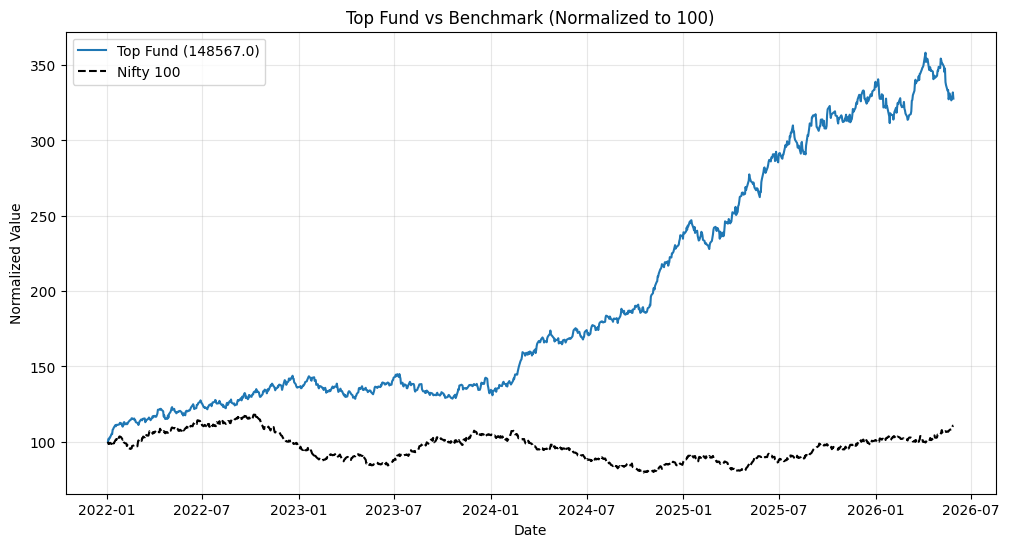

In [6]:
if 'cagr_report' in locals() and 'df_sharpe' in locals() and 'alpha_beta' in locals():
    # Build Scorecard
    scorecard = cagr_report.merge(df_sharpe, on='amfi_code').merge(df_sortino, on='amfi_code').merge(alpha_beta, on='amfi_code').merge(max_dd, on='amfi_code')
    
    # Basic ranking score (Higher is better for 3yr, Sharpe, Alpha; Lower is better for Max DD)
    scorecard['score'] = (
        scorecard['3yr_cagr'].rank(pct=True) * 0.3 +
        scorecard['sharpe_ratio'].rank(pct=True) * 0.3 +
        scorecard['alpha'].rank(pct=True) * 0.2 +
        scorecard['max_drawdown_pct'].rank(pct=True) * 0.2 # max dd is negative, so rank ascending is correct for worst, but wait we want higher score for better (closer to 0)
    ) * 100
    
    scorecard.to_csv('../data/processed/fund_scorecard.csv', index=False)
    print("Fund Scorecard generated.")
    
    # Plot top fund vs Nifty 100
    top_fund_code = scorecard.sort_values('score', ascending=False).iloc[0]['amfi_code']
    top_fund_data = df_nav[df_nav['amfi_code'] == top_fund_code].set_index('date')
    bench_data = df_bench_nifty.set_index('date')
    
    plt.figure(figsize=(12, 6))
    
    # Normalize to 100
    if not top_fund_data.empty and not bench_data.empty:
        common_start = max(top_fund_data.index.min(), bench_data.index.min())
        tf_norm = top_fund_data.loc[common_start:]['nav'] / top_fund_data.loc[common_start]['nav'] * 100
        bn_norm = bench_data.loc[common_start:]['close_value'] / bench_data.loc[common_start]['close_value'] * 100
        
        plt.plot(tf_norm.index, tf_norm, label=f'Top Fund ({top_fund_code})')
        plt.plot(bn_norm.index, bn_norm, label='Nifty 100', color='black', linestyle='--')
        
    plt.title('Top Fund vs Benchmark (Normalized to 100)')
    plt.xlabel('Date')
    plt.ylabel('Normalized Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('../data/processed/benchmark_chart.png', bbox_inches='tight')
    plt.show()